В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [615]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, RocCurveDisplay, accuracy_score
from process_bank_churn import preprocess_data, preprocess_new_data
# https://github.com/verabalashova/python-for-ml-tasks/blob/main/module-2/topic-2/process_bank_churn.py

In [616]:
raw_df = pd.read_csv('train.csv')

processed_data_result = preprocess_data(raw_df)
#display(processed_data_result)

X_train = processed_data_result['train_X']
train_targets = processed_data_result['train_y']
X_val = processed_data_result['val_X']
val_targets = processed_data_result['val_y']

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [617]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, train_targets)

DecisionTreeClassifier(random_state=42)

In [618]:
def predict_and_plot(model_param, inputs, targets, name=''):
  # 1. Predict probabilities for the positive class
  probs = model_param.predict_proba(inputs)[:, 1]

  # 2. Predict the class labels
  preds = model_param.predict(inputs)

  # 3. Calculate and display the Confusion Matrix
  conf_matrix = confusion_matrix(targets, preds, normalize='true')
  print("Confusion Matrix ({name}):\n", conf_matrix)

  # 4. Calculate and display the F1 Score
  f1 = f1_score(targets, preds)
  print("F1 score: {:.2f}%".format(f1 * 100))

  # 5. Calculate and display the AUROC score
  roc_auc = roc_auc_score(targets, probs)
  print(f"AUROC Score ({name}): {roc_auc:.4f}")

  #6. Confusion Matrix plot:
  plt.figure()
  sns.heatmap(conf_matrix, annot=True)
  plt.xlabel('Prediction')
  plt.ylabel('Target')
  plt.title('{} Confusion Matrix'.format(name));

  return probs, preds

In [619]:
def roc_curve_train_vs_validation(model_param, inputs_train, targets_train, inputs_val, targets_val):
  plt.figure(figsize=(10, 8))
  ax = plt.gca()

  RocCurveDisplay.from_estimator(model_param, inputs_train, targets_train, ax=ax, name='Train Data ROC')
  RocCurveDisplay.from_estimator(model_param, inputs_val, targets_val, ax=ax, name='Validation Data ROC')

  plt.title('ROC Curve - Train vs Validation Data')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
  plt.legend()
  plt.grid(True)
  plt.show()
  return

Confusion Matrix ({name}):
 [[1. 0.]
 [0. 1.]]
F1 score: 100.00%
AUROC Score (Training Data): 1.0000


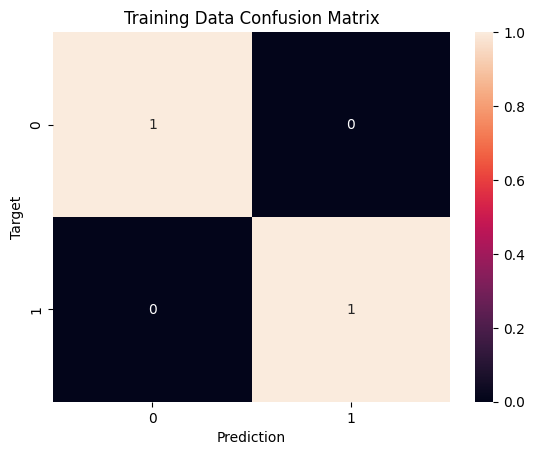

In [620]:
(train_probs, train_preds) = predict_and_plot(model, X_train, train_targets, 'Training Data')

Confusion Matrix ({name}):
 [[0.89456067 0.10543933]
 [0.4        0.6       ]]
F1 score: 59.61%
AUROC Score (Validation Data): 0.7473


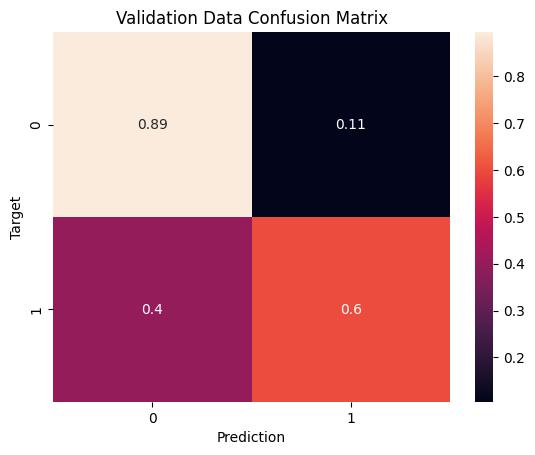

In [621]:
(val_probs, val_preds) = predict_and_plot(model, X_val, val_targets, 'Validation Data')

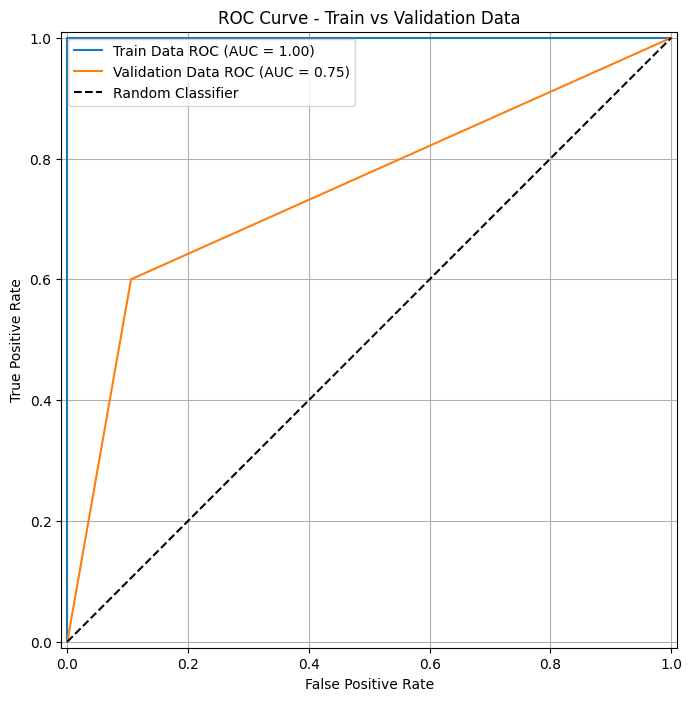

In [622]:
roc_curve_train_vs_validation(model, X_train, train_targets, X_val, val_targets)

### Спостереження
Я б сказала, що модель перетренована (overfit): ROC AUC Score 1.0.  

In [623]:
display(f"Max tree depth: {model.tree_.max_depth}")

'Max tree depth: 27'

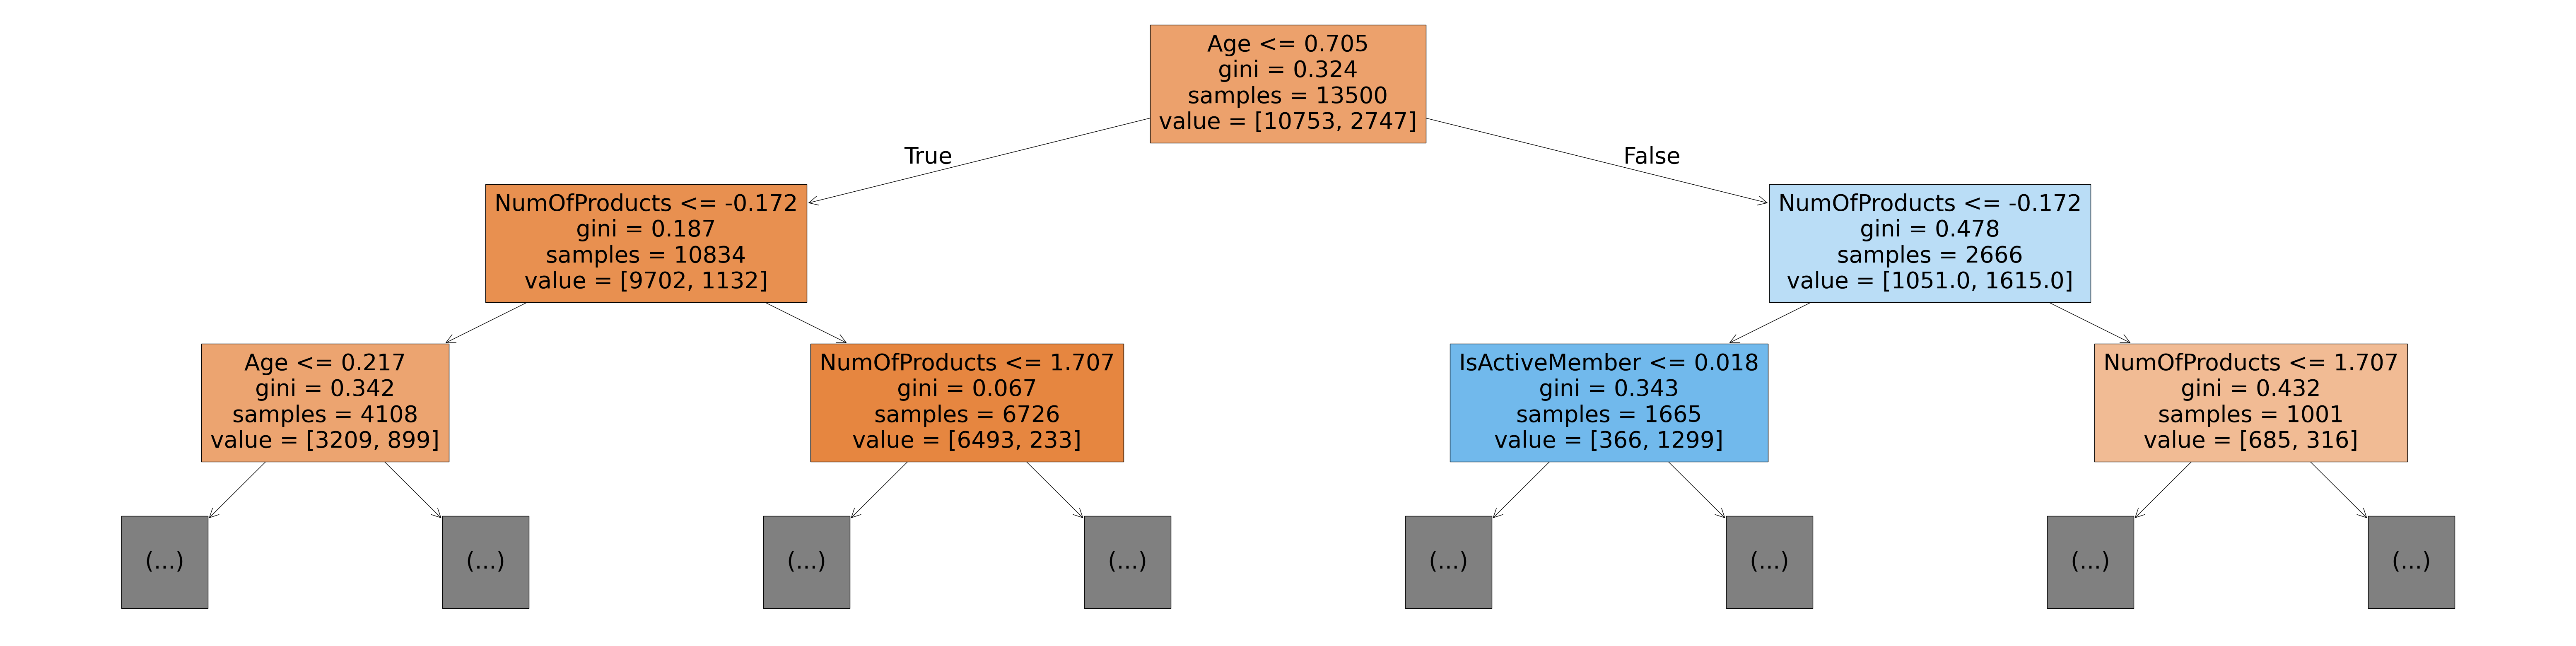

In [624]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True);

### Спостереження

Найвпливовіші ознаки:
- `Age`
- `NumOfProducts`
- `IsActiveMember`

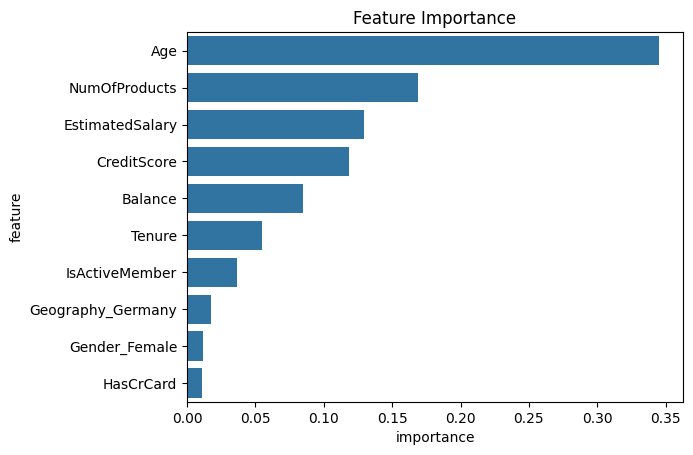

In [625]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

### Tuned model 1

In [626]:
# Tune #1
model_tuned_1 = DecisionTreeClassifier(random_state=42, max_depth=5)

model_tuned_1.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=5, random_state=42)

Confusion Matrix ({name}):
 [[0.97163582 0.02836418]
 [0.40516928 0.59483072]]
F1 score: 69.74%
AUROC Score (Training Data): 0.9270


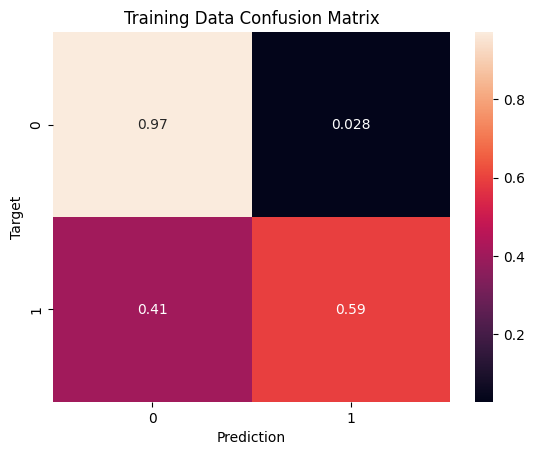

In [627]:
(train_probs_tuned_1, train_preds_tuned_1) = predict_and_plot(model_tuned_1, X_train, train_targets, 'Training Data')

Confusion Matrix ({name}):
 [[0.96317992 0.03682008]
 [0.44918033 0.55081967]]
F1 score: 64.99%
AUROC Score (Validation Data): 0.9135


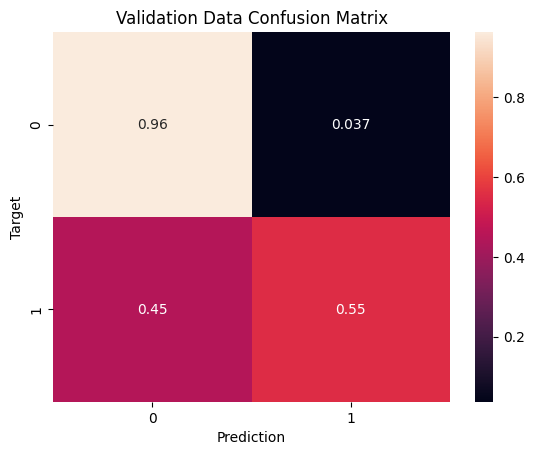

In [628]:
(val_probs_tuned_1, val_preds_tuned_1) = predict_and_plot(model_tuned_1, X_val, val_targets, 'Validation Data')

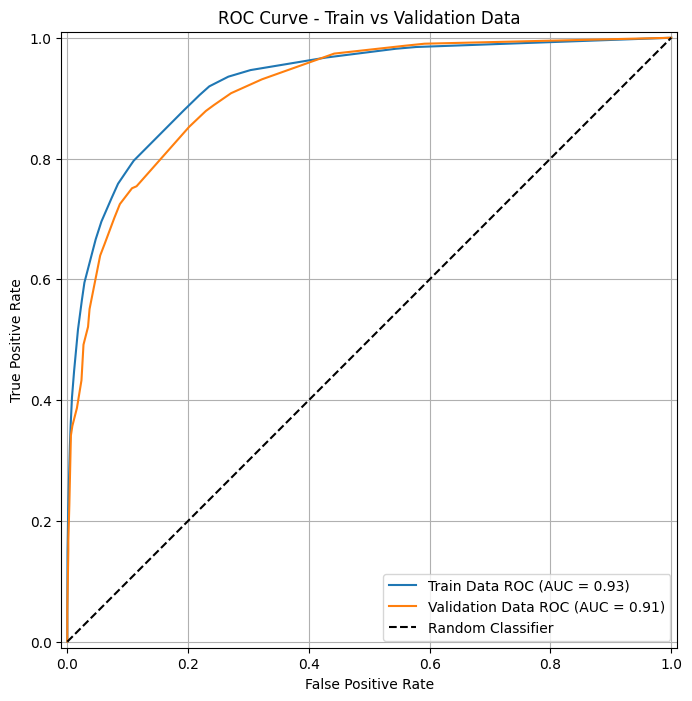

In [629]:
roc_curve_train_vs_validation(model_tuned_1, X_train, train_targets, X_val, val_targets)

### Tuned model 2

In [630]:
# Tune #2
model_tuned_2 = DecisionTreeClassifier(random_state=42, max_leaf_nodes=56)

model_tuned_2.fit(X_train, train_targets)

DecisionTreeClassifier(max_leaf_nodes=56, random_state=42)

Confusion Matrix ({name}):
 [[0.96075514 0.03924486]
 [0.28540226 0.71459774]]
F1 score: 76.50%
AUROC Score (Training Data): 0.9325


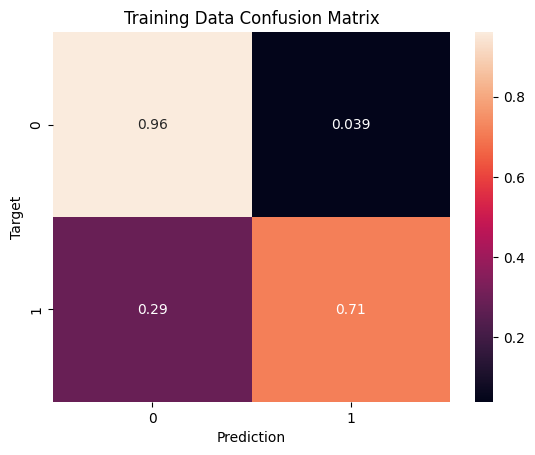

In [631]:
(train_probs_tuned_2, train_preds_tuned_2) = predict_and_plot(model_tuned_2, X_train, train_targets, 'Training Data')

Confusion Matrix ({name}):
 [[0.93556485 0.06443515]
 [0.36065574 0.63934426]]
F1 score: 67.59%
AUROC Score (Validation Data): 0.9098


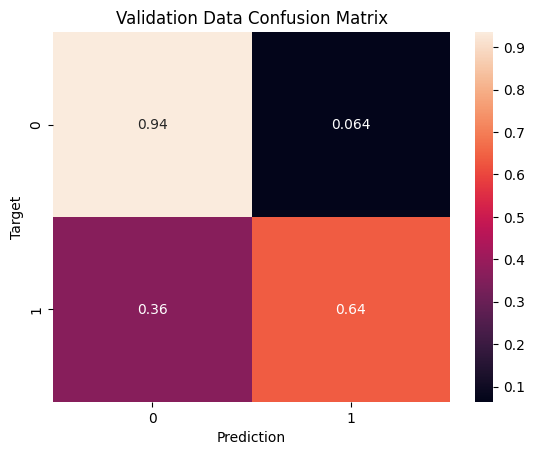

In [632]:
(val_probs_tuned_2, val_preds_tuned_2) = predict_and_plot(model_tuned_2, X_val, val_targets, 'Validation Data')

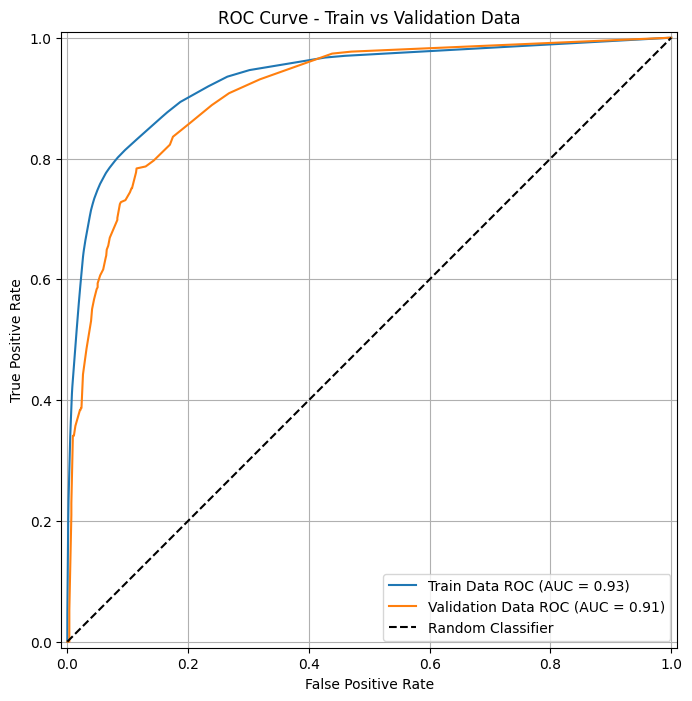

In [633]:
roc_curve_train_vs_validation(model_tuned_2, X_train, train_targets, X_val, val_targets)

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [634]:
def max_depth_error(md):
    model_md = DecisionTreeClassifier(max_depth=md, random_state=42)
    model_md.fit(X_train, train_targets)

    probs_train = model_md.predict_proba(X_train)[:, 1]
    probs_val = model_md.predict_proba(X_val)[:, 1]

    train_auroc =  roc_auc_score(train_targets, probs_train)
    val_auroc = roc_auc_score(val_targets, probs_val)
    return {'Max Depth': md, 'Training AUROC': train_auroc, 'Validation AUROC': val_auroc}

In [635]:
auroc_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

In [636]:
auroc_df.style.background_gradient(subset='Validation AUROC', cmap='Blues')

,Max Depth,Training AUROC,Validation AUROC
0,1,0.745087,0.721750
1,2,0.844342,0.837315
2,3,0.897229,0.884929
3,4,0.912152,0.903541
4,5,0.927044,0.913481
5,6,0.934688,0.912919
6,7,0.941551,0.902353
7,8,0.948975,0.885921
8,9,0.957694,0.874174
9,10,0.968247,0.840255


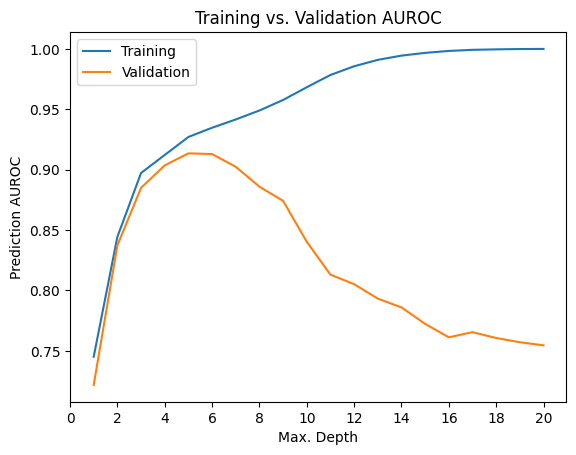

In [637]:
plt.figure()
plt.plot(auroc_df['Max Depth'], auroc_df['Training AUROC'])
plt.plot(auroc_df['Max Depth'], auroc_df['Validation AUROC'])
plt.title('Training vs. Validation AUROC')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction AUROC')
plt.legend(['Training', 'Validation']);

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [638]:
test_df = pd.read_csv('test.csv')
X_test = preprocess_new_data(test_df,
                                          processed_data_result['numeric_cols'],
                                          processed_data_result['categorical_cols'],
                                          processed_data_result['encoded_cols'],
                                          processed_data_result['scaler'],
                                          processed_data_result['encoder'])
#display(processed_test_data)

model_final = DecisionTreeClassifier(random_state=42, max_depth=5)
model_final.fit(X_train, train_targets)

test_prob = model_final.predict_proba(X_test)[:, 1]
test_df['Exited'] = test_prob

submission_df = pd.read_csv('sample_submission.csv')
display('Read from a file: ', submission_df[:5])
print()
print('------------------')
print()

submission_df['Exited'] = test_df['Exited']
display('Predictied with decition tree model: ', submission_df[:5])

submission_df.to_csv('submission_dec_tree.csv', index=False)

'Read from a file: '

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5



------------------



'Predictied with log model: '

,id,Exited
0,15000,0.198847
1,15001,0.031177
2,15002,0.031177
3,15003,0.639344
4,15004,0.031177
